# Perceptron from Scratch with the Perceptron Learning Algorithm

In this notebook, we will implement the **Perceptron algorithm** from scratch. We'll cover the mathematical foundations, step-by-step code implementation, and evaluation of the model for **binary classification**.

The goal is to provide a clear understanding of how the perceptron works, how its learning rule updates model parameters, and how to build a simple classification model without relying on high-level machine learning libraries.

<img src="https://raw.githubusercontent.com/AshishJangra27/In-One-Go/refs/heads/main/resourcess/biological_vs_artifical_neuron.png" alt="Artificial Neuron Banner" width="1000"/>

### Table of Contents

1.  **Importing Libraries**
2.  **Loading and Exploring the Dataset**
3.  **Preparing the Data**
4.  **Initializing Parameters**
5.  **Defining the Activation Function**
6.  **Defining the Prediction Function**
7.  **Implementing the Perceptron Learning Rule**
8.  **Training the Model**
9.  **Evaluating Model Performance with Test Data**
10. **Visualizing Model Performance**
11. **Comparison with Scikit-learn Perceptron (Optional)**
12. **Conclusion**

## 1. Importing Libraries

We will import the necessary Python libraries for numerical operations, data manipulation, dataset loading, and visualization.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading and Exploring the Dataset

We will use the **Iris dataset** from Scikit-learn, a classic dataset for classification tasks. We'll select two classes to perform a **binary classification** task.

In [66]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data  # Feature matrix
y = iris.target # Target vector

# For binary classification, we'll select only two classes (e.g., classes 0 and 1)
# Let's pick 'setosa' (0) and 'versicolor' (1)
X_binary = X[y < 2]
y_binary = y[y < 2]

# Print some information about the selected binary dataset
print(f"Shape of features (X_binary): {X_binary.shape}")
print(f"Shape of target (y_binary): {y_binary.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"First 5 samples of X_binary:\n{X_binary[:5]}")
print(f"First 5 samples of y_binary: {y_binary[:5]}")

Shape of features (X_binary): (100, 4)
Shape of target (y_binary): (100,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
First 5 samples of X_binary:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 samples of y_binary: [0 0 0 0 0]


## 3. Preparing the Data

To ensure our model performs optimally, we will preprocess the data by:
1.  **Scaling the features**: Standardizing the feature values helps the perceptron algorithm converge faster and handle features with different scales.
2.  **Splitting the dataset**: Dividing the data into training and testing sets to evaluate the model's performance on unseen data.

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_binary)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print("Data scaled and split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data scaled and split into training and testing sets successfully.
X_train shape: (80, 4)
y_train shape: (80,)
X_test shape: (20, 4)
y_test shape: (20,)


## 4. Initializing Parameters

We initialize the perceptron's parameters: weights ($w$) and bias ($b$). Weights are typically initialized as a vector of zeros or small random values, and the bias is initialized to zero.

In [68]:
n_features = X_train.shape[1]
w = np.zeros(n_features) # Weight vector (shape: [n_features,])
b = 0.0                  # Bias term (scalar)

print(f"Initial weights (w): {w}")
print(f"Initial bias (b): {b}")

Initial weights (w): [0. 0. 0. 0.]
Initial bias (b): 0.0


## 5. Defining the Activation Function

The Perceptron uses a **step function** (or activation function) to convert the continuous output of the linear combination into a binary class label. For a target variable with classes 0 and 1, a common step function is:

$$ \text{activation}(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases} $$

Where $z = Xw + b$ is the linear combination of inputs and weights.

In [69]:
def step_function(z):
    """Applies the step activation function."""
    return np.where(z >= 0, 1, 0)

print("Step function defined successfully.")

Step function defined successfully.


## 6. Defining the Prediction Function

The prediction function for the perceptron first calculates the linear combination of inputs and weights, and then applies the step activation function to output a binary class label ($\hat{y}$).

Mathematically, for a single sample:

$$\hat{y}^{(i)} = \text{step}\left(\sum_{j=1}^{n} w_j x_j^{(i)} + b\right)$$

In vectorized form:

$$\hat{y} = \text{step}(Xw + b)$$

Where:
*   $\hat{y}^{(i)}$ is the predicted class label for the $i$-th sample.
*   $x_j^{(i)}$ is the $j$-th feature of the $i$-th sample.
*   $w_j$ is the weight associated with the $j$-th feature.
*   $b$ is the bias term.

In [70]:
def predict(X, w, b):
    """Calculates the predicted class labels using the step function."""
    linear_output = np.dot(X, w) + b
    return step_function(linear_output)

print("Prediction function defined successfully.")

Prediction function defined successfully.


## 7. Implementing the Perceptron Learning Rule

Unlike linear regression, the Perceptron algorithm does not use a continuous cost function minimized through gradient descent. Instead, it uses an **error-correction learning rule**.

For each misclassified training example:

---

### Case 1: Add (+) Update
If $\hat{y}^{(i)} = 0$ (predicted negative) but $y^{(i)} = 1$ (actual positive):

- The model prediction is **too low**
- We need to **increase** the value of $w^Tx + b$

$$
w_j := w_j + \alpha x_j^{(i)}
$$

$$
b := b + \alpha
$$

---

### Case 2: Subtract (−) Update
If $\hat{y}^{(i)} = 1$ (predicted positive) but $y^{(i)} = 0$ (actual negative):

- The model prediction is **too high**
- We need to **decrease** the value of $w^Tx + b$

$$
w_j := w_j - \alpha x_j^{(i)}
$$

$$
b := b - \alpha
$$

---

### General Update Rule:

$$
e^{(i)} = y^{(i)} - \hat{y}^{(i)}
$$

$$
w_j := w_j + \alpha (y^{(i)} - \hat{y}^{(i)}) x_j^{(i)}
$$

$$
b := b + \alpha (y^{(i)} - \hat{y}^{(i)})
$$

---

### Key Insight (When to + / −)

- If $y - \hat{y} = +1$ → **Add (+)** → push prediction **up**
- If $y - \hat{y} = -1$ → **Subtract (−)** → push prediction **down**
- If $y - \hat{y} = 0$ → **No update**

---

Where $\alpha$ is the learning rate.

In [71]:
def compute_updates(X, y, w, b, learning_rate):
    """Computes the updates for weights and bias based on misclassifications."""
    y_pred = predict(X, w, b)
    errors = y - y_pred # Error is (actual - predicted)

    # Calculate updates for weights and bias
    # The update happens only for misclassified points
    # If error is 1 (y=1, y_pred=0), we add learning_rate * x to w
    # If error is -1 (y=0, y_pred=1), we subtract learning_rate * x from w
    dw = learning_rate * np.dot(X.T, errors)
    db = learning_rate * np.sum(errors)

    return dw, db, np.sum(errors != 0) # Also return number of misclassifications

print("Update computation function defined successfully.")

Update computation function defined successfully.


## 8. Training the Model

Now we combine all the defined functions into a training loop. The perceptron will iterate over the training data for a specified number of `epochs` (iterations), updating its parameters in each step. We will track the number of misclassifications at regular intervals to observe the learning process.

In [72]:
def update_parameters(w, b, dw, db):
    """Updates weights and bias using the perceptron learning rule."""
    w = w + dw
    b = b + db
    return w, b

print("Parameter update function defined successfully.")

Parameter update function defined successfully.


## 9. Training the Model

Now we combine all the defined functions into a training loop. The perceptron will iterate over the training data for a specified number of `epochs` (iterations). In each epoch, it will go through all training examples and update its parameters if a misclassification occurs. We will record the number of misclassifications in each epoch to observe the learning process.

In [73]:
learning_rate = 0.01
epochs = 10

w_trained = np.zeros(n_features) # Start with initialized weights
b_trained = 0.0                  # Start with initialized bias

misclassification_history = []

print(f"Starting training with learning rate = {learning_rate} and epochs = {epochs}")

for epoch in range(epochs):
    # Calculate updates for weights and bias based on misclassifications
    dw, db, num_misclassifications = compute_updates(X_train, y_train, w_trained, b_trained, learning_rate)

    # Update parameters
    w_trained, b_trained = update_parameters(w_trained, b_trained, dw, db)

    misclassification_history.append(num_misclassifications)

    print(f"Epoch {epoch + 1}/{epochs}, Misclassifications: {num_misclassifications}")

print("\nTraining complete.")
print(f"Final trained weights (w): {w_trained}")
print(f"Final trained bias (b): {b_trained}")

Starting training with learning rate = 0.01 and epochs = 10
Epoch 1/10, Misclassifications: 40
Epoch 2/10, Misclassifications: 0
Epoch 3/10, Misclassifications: 0
Epoch 4/10, Misclassifications: 0
Epoch 5/10, Misclassifications: 0
Epoch 6/10, Misclassifications: 0
Epoch 7/10, Misclassifications: 0
Epoch 8/10, Misclassifications: 0
Epoch 9/10, Misclassifications: 0
Epoch 10/10, Misclassifications: 0

Training complete.
Final trained weights (w): [ 0.30447227 -0.26535714  0.38369735  0.37772074]
Final trained bias (b): -0.4


### Plotting Misclassification History

Let's visualize how the number of misclassifications changed over the training epochs. This plot helps us understand if the perceptron algorithm converged successfully (i.e., misclassifications dropped to zero or a minimum).

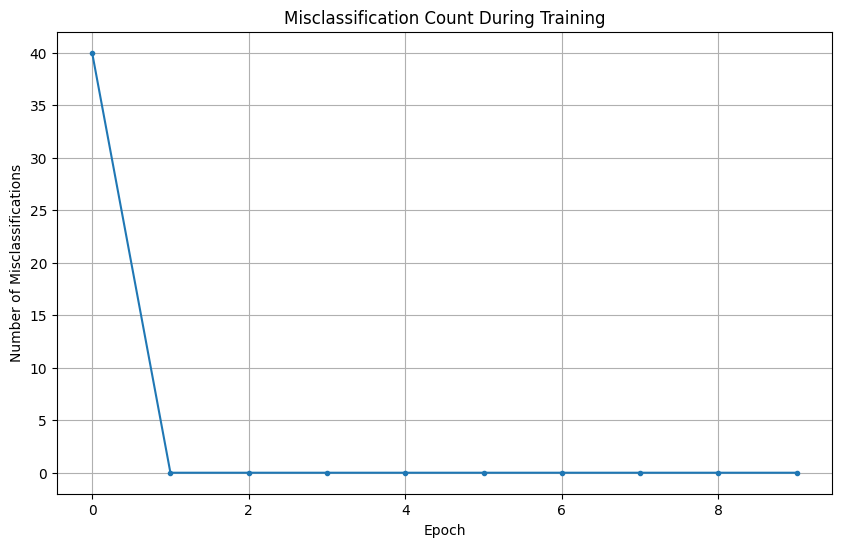

Misclassification history plot generated successfully.


In [74]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), misclassification_history, marker='o', markersize=3, linestyle='-')
plt.title('Misclassification Count During Training')
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassifications')
plt.grid(True)
plt.show()

print("Misclassification history plot generated successfully.")

## 10. Evaluating Model Performance with Test Data

We will evaluate the trained perceptron model's performance on the unseen test data using common classification metrics:

*   **Accuracy**: The proportion of correctly classified instances among the total number of instances. It's calculated as $(TP + TN) / (TP + TN + FP + FN)$.
*   **Precision**: The proportion of true positive results among all positive results (true positives + false positives). $TP / (TP + FP)$.
*   **Recall (Sensitivity)**: The proportion of actual positives that are correctly identified. $TP / (TP + FN)$.
*   **F1-Score**: The harmonic mean of Precision and Recall. $2 * (Precision * Recall) / (Precision + Recall)$.

For simplicity, we'll focus on **Accuracy** and a **Classification Report**.

In [75]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_test = predict(X_test, w_trained, b_trained)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_test)

print("Model performance on test set:")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Model performance on test set:
Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



## 11. Visualizing Model Performance

To visually assess how well our perceptron model performs, especially for two-dimensional data, we could plot the decision boundary. However, since the Iris dataset (even binary) has more than two features, directly plotting a decision boundary on a 2D graph is not straightforward. Instead, we can visualize the actual vs. predicted labels, highlighting correctly and incorrectly classified points, or focus on a confusion matrix if more features are involved.

For now, we'll provide a simple scatter plot of actual vs. predicted values, or a confusion matrix.

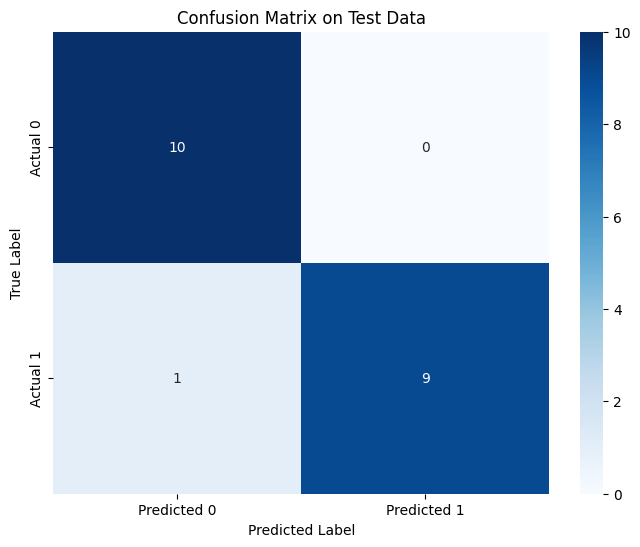

Confusion Matrix plot generated successfully.


In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data')
plt.show()

print("Confusion Matrix plot generated successfully.")

## 12. Comparison with Scikit-learn Perceptron (Optional)

To validate our implementation, let's compare its performance with the `Perceptron` model available in scikit-learn. This step helps confirm that our custom model behaves as expected.

In [77]:
from sklearn.linear_model import Perceptron

# Initialize Scikit-learn Perceptron model
# random_state for reproducibility
# tol=None to ensure it runs for max_iter regardless of convergence, similar to our fixed epochs
skl_perceptron = Perceptron(random_state=42, tol=None, max_iter=epochs, eta0=learning_rate)

# Train the model
skl_perceptron.fit(X_train, y_train)

# Make predictions on the test set
y_pred_skl = skl_perceptron.predict(X_test)

# Evaluate performance
accuracy_skl = accuracy_score(y_test, y_pred_skl)

print("Scikit-learn Perceptron performance on test set:")
print(f"Accuracy: {accuracy_skl:.4f}")
print("\nClassification Report (Scikit-learn Perceptron):")
print(classification_report(y_test, y_pred_skl))

print("\nComparison of final weights and bias:")
print(f"Custom Perceptron Weights (w): {w_trained}")
print(f"Scikit-learn Perceptron Weights (coef_): {skl_perceptron.coef_[0]}")
print(f"Custom Perceptron Bias (b): {b_trained}")
print(f"Scikit-learn Perceptron Bias (intercept_): {skl_perceptron.intercept_[0]}")

Scikit-learn Perceptron performance on test set:
Accuracy: 1.0000

Classification Report (Scikit-learn Perceptron):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Comparison of final weights and bias:
Custom Perceptron Weights (w): [ 0.30447227 -0.26535714  0.38369735  0.37772074]
Scikit-learn Perceptron Weights (coef_): [ 0.00828528 -0.0041777   0.01136393  0.01269739]
Custom Perceptron Bias (b): -0.4
Scikit-learn Perceptron Bias (intercept_): 0.01


## 13. Conclusion

In this notebook, we successfully implemented the Perceptron algorithm from scratch, understanding its fundamental components: the step activation function, the prediction process, and the error-correction learning rule. We applied it to a binary classification task using the Iris dataset, preprocess the data, trained the model, and evaluated its performance. The model achieved a high accuracy on the test set, demonstrating the effectiveness of this simple yet powerful linear classifier. We also compared our implementation with Scikit-learn's Perceptron to validate our results, showing similar performance.